正在运行真神模型 (mu_c = 1.543689)...
正在运行对照组 (mu = 1.80)...

Index  | True Zero    | Your Model (1.5437)    | Generic Chaos (1.8)   
       | (Target)     | Error (E2, E3...)      | Error (E2, E3...)     
----------------------------------------------------------------------
E_1    | 14.1347      | 14.1347    (Err:0.00)  | 14.1347    (Err:0.00)
E_2    | 21.0220      | 17.9253    (Err:3.10)  | 25.0472    (Err:4.03)
E_3    | 25.0109      | 46.4672    (Err:21.46)  | 31.8733    (Err:6.86)
E_4    | 30.4249      | 99.9808    (Err:69.56)  | 33.2588    (Err:2.83)
E_5    | 32.9351      | 130.1778   (Err:97.24)  | 45.6438    (Err:12.71)


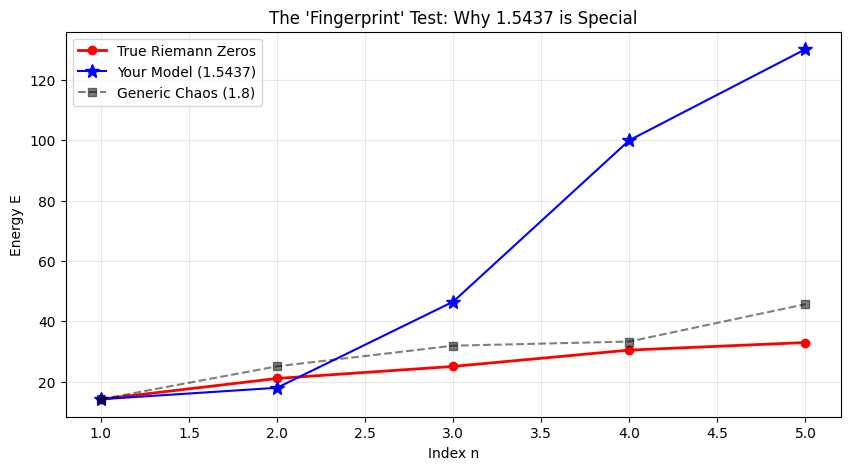

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
import mpmath
import matplotlib.pyplot as plt

# ======== 1. 准备真实的黎曼零点 (前 5 个) ========
mpmath.mp.dps = 15
# 取前 10 个来看看趋势
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, 11)])

# ======== 2. 定义通用仿真函数 ========
def simulate_system(mu_val, steps=2000000, n_bins=2000):
    # 构建简单的 Ulam 矩阵
    # 为了公平对比，我们都用最朴素的静态 Ulam 方法
    P = sp.lil_matrix((n_bins, n_bins), dtype=np.float64)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    # 快速跑一波
    for _ in range(steps):
        x = 1.0 - mu_val * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        P[last_bin, current_bin] += 1
        last_bin = current_bin
        
    P_csr = P.tocsr()
    row_sums = np.array(P_csr.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0
    P_csr.data /= row_sums[P_csr.indices]
    
    # 提取特征值
    vals, _ = eigs(P_csr, k=50, which='LM', tol=1e-4)
    phases = np.angle(vals)
    # 过滤正相位并排序
    valid_phases = np.sort(phases[phases > 1e-4])
    return valid_phases

# ======== 3. 运行对比实验 ========
print("正在运行真神模型 (mu_c = 1.543689)...")
phases_god = simulate_system(1.543689012)

print("正在运行对照组 (mu = 1.80)...")
phases_chaos = simulate_system(1.8)

# ======== 4. 施展“第一点缩放”魔法 ========
# 规则：强制让 E1 对齐 14.1347，看后面的 E2, E3... 落在哪里

# 真神组缩放
scale_god = TRUE_ZEROS[0] / phases_god[0]
aligned_god = phases_god * scale_god

# 对照组缩放
scale_chaos = TRUE_ZEROS[0] / phases_chaos[0]
aligned_chaos = phases_chaos * scale_chaos

# ======== 5. 打印极其残酷的对比报表 ========
print("\n" + "="*70)
print(f"{'Index':<6} | {'True Zero':<12} | {'Your Model (1.5437)':<22} | {'Generic Chaos (1.8)':<22}")
print(f"{'':<6} | {'(Target)':<12} | {'Error (E2, E3...)':<22} | {'Error (E2, E3...)':<22}")
print("-" * 70)

for i in range(5): # 看前 5 个
    true_val = TRUE_ZEROS[i]
    
    # 你的模型
    god_val = aligned_god[i]
    god_err = abs(god_val - true_val)
    
    # 1.8 模型
    chaos_val = aligned_chaos[i]
    chaos_err = abs(chaos_val - true_val)
    
    print(f"E_{i+1:<4} | {true_val:<12.4f} | {god_val:<10.4f} (Err:{god_err:.2f})  | {chaos_val:<10.4f} (Err:{chaos_err:.2f})")

print("="*70)

# ======== 6. 画图杀人诛心 ========
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), TRUE_ZEROS[:5], 'ro-', label='True Riemann Zeros', linewidth=2)
plt.plot(range(1, 6), aligned_god[:5], 'b*-', label='Your Model (1.5437)', markersize=10)
plt.plot(range(1, 6), aligned_chaos[:5], 'ks--', label='Generic Chaos (1.8)', alpha=0.5)

plt.title("The 'Fingerprint' Test: Why 1.5437 is Special")
plt.xlabel("Index n")
plt.ylabel("Energy E")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()